In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/ethiopia.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:", df.columns.tolist())

Shape of dataset: (4108, 12)

First 5 rows:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58



Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']


In [4]:
# Add country column
df['Country'] = 'Ethiopia'

# Convert YEAR and DOY to datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

print("Date conversion successful!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Date conversion successful!
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [5]:
# Replace -999 with NaN
df = df.replace(-999, np.nan)

print("Missing values after replacing -999:")
print(df.isna().sum())

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Year           0
Month          0
Month_Name     0
dtype: int64


In [6]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


In [7]:
print("=== Summary Statistics ===")
display(df.describe())

# Missing value percentage
missing_percent = (df.isna().sum() / len(df)) * 100
print("\n=== Missing Values (%) ===")
print(missing_percent[missing_percent > 0])

=== Summary Statistics ===


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.248907,3.477046



=== Missing Values (%) ===
Series([], dtype: float64)


In [8]:
# Outlier Detection using Z-score for key columns
key_columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("=== Outlier Detection (Z-score > 3) ===\n")

for col in key_columns:
    if col in df.columns:
        # Calculate Z-score
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        outliers = z_scores > 3
        count = outliers.sum()
        print(f"{col:12}: {count:5} outliers ({count/len(df)*100:5.2f}%)")
        

=== Outlier Detection (Z-score > 3) ===

T2M         :     3 outliers ( 0.07%)
T2M_MAX     :     0 outliers ( 0.00%)
T2M_MIN     :    18 outliers ( 0.44%)
PRECTOTCORR :    95 outliers ( 2.31%)
RH2M        :    13 outliers ( 0.32%)
WS2M        :     3 outliers ( 0.07%)
WS2M_MAX    :     5 outliers ( 0.12%)


In [9]:
# Make a copy for cleaning
df_clean = df.copy()

# Strategy: Forward fill for weather time series data (reasonable for consecutive days)
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

print("Filling missing values using forward fill...")

for col in weather_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].ffill()

# Check if any missing values remain
remaining_missing = df_clean.isna().sum().sum()
print(f"Remaining missing values after forward fill: {remaining_missing}")

# Drop any row that still has too many missing values (optional safety)
if remaining_missing > 0:
    df_clean = df_clean.dropna()
    print("Dropped rows with remaining NaNs.")

print("\nFinal shape after cleaning:", df_clean.shape)

Filling missing values using forward fill...
Remaining missing values after forward fill: 0

Final shape after cleaning: (4108, 17)


In [10]:
# Create data folder if not exists (already should exist)
import os
os.makedirs('../data', exist_ok=True)

# Save cleaned version
df_clean.to_csv('../data/ethiopia_clean.csv', index=False)
print("✅ Cleaned Ethiopia data saved to: ../data/ethiopia_clean.csv")

✅ Cleaned Ethiopia data saved to: ../data/ethiopia_clean.csv


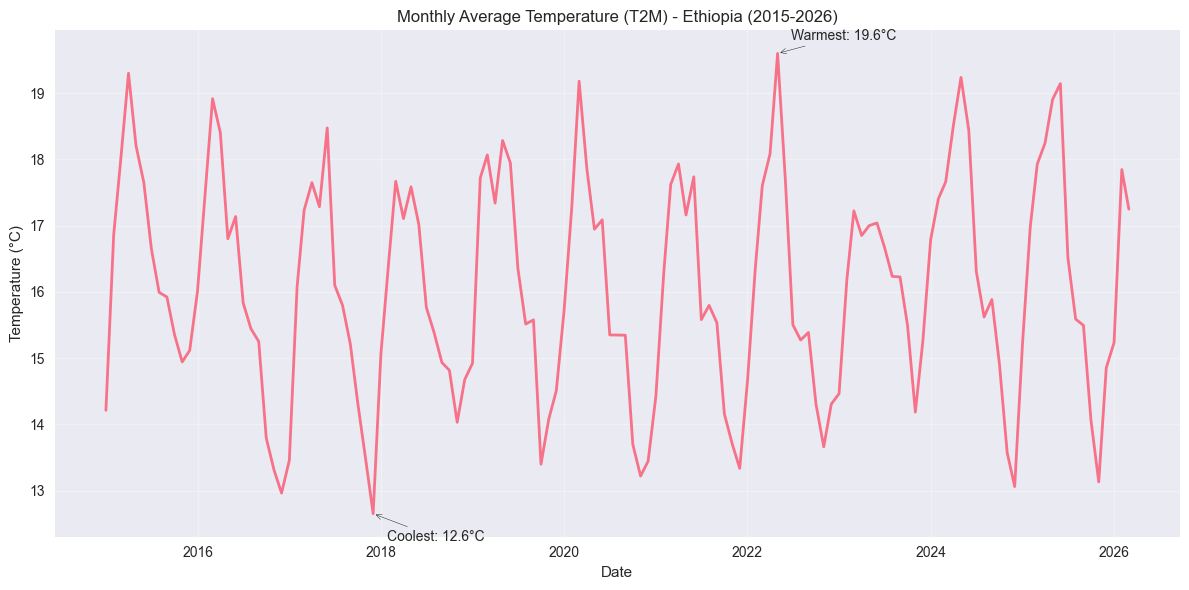

In [11]:
# Monthly average temperature
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + 
                                      monthly_temp['Month'].astype(str) + '-01')

plt.figure(figsize=(12, 6))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], linewidth=2)
plt.title('Monthly Average Temperature (T2M) - Ethiopia (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

# Annotate warmest and coolest months overall
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

plt.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
             xy=(warmest['Date'], warmest['T2M']),
             xytext=(10, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->'))

plt.annotate(f'Coolest: {coolest["T2M"]:.1f}°C', 
             xy=(coolest['Date'], coolest['T2M']),
             xytext=(10, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

C:\Users\elsam\AppData\Local\Temp\ipykernel_18008\1023932745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='PRECTOTCORR', data=avg_monthly_precip, palette='Blues_d')


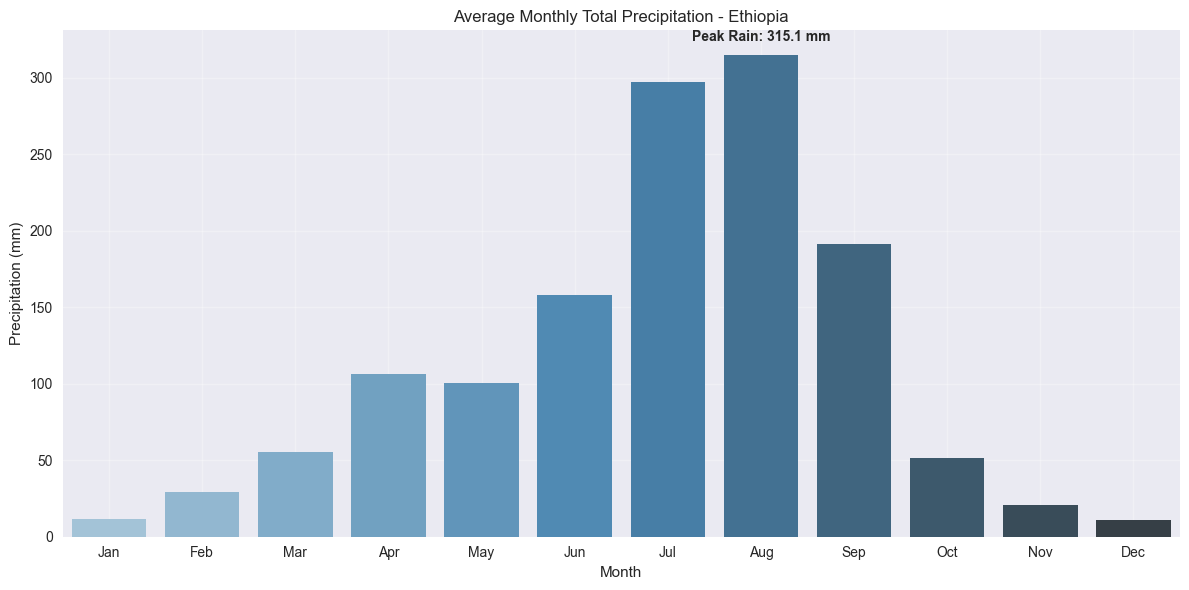

In [12]:
# Monthly total precipitation
monthly_precip = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + 
                                        monthly_precip['Month'].astype(str) + '-01')

# Average monthly precipitation across all years
avg_monthly_precip = monthly_precip.groupby('Month')['PRECTOTCORR'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='PRECTOTCORR', data=avg_monthly_precip, palette='Blues_d')
plt.title('Average Monthly Total Precipitation - Ethiopia')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

# Annotate peak rainy season
peak_month = avg_monthly_precip.loc[avg_monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f'Peak Rain: {peak_month["PRECTOTCORR"]:.1f} mm', 
             xy=(peak_month['Month']-1, peak_month['PRECTOTCORR']),
             xytext=(0, 10), textcoords='offset points',
             ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

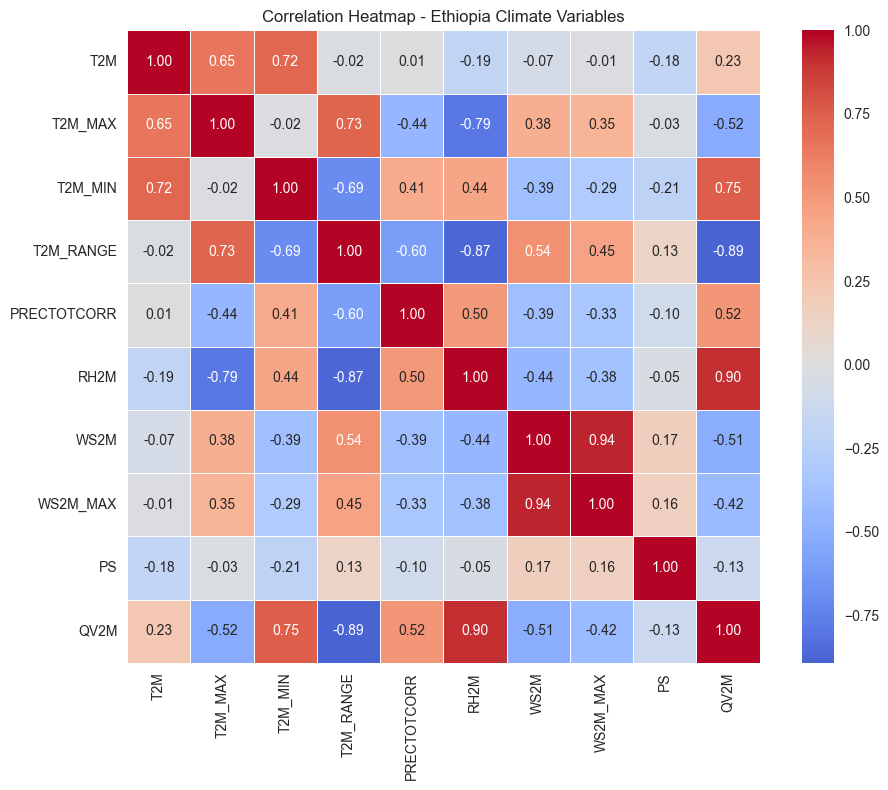

In [13]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                        'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Ethiopia Climate Variables')
plt.tight_layout()
plt.show()

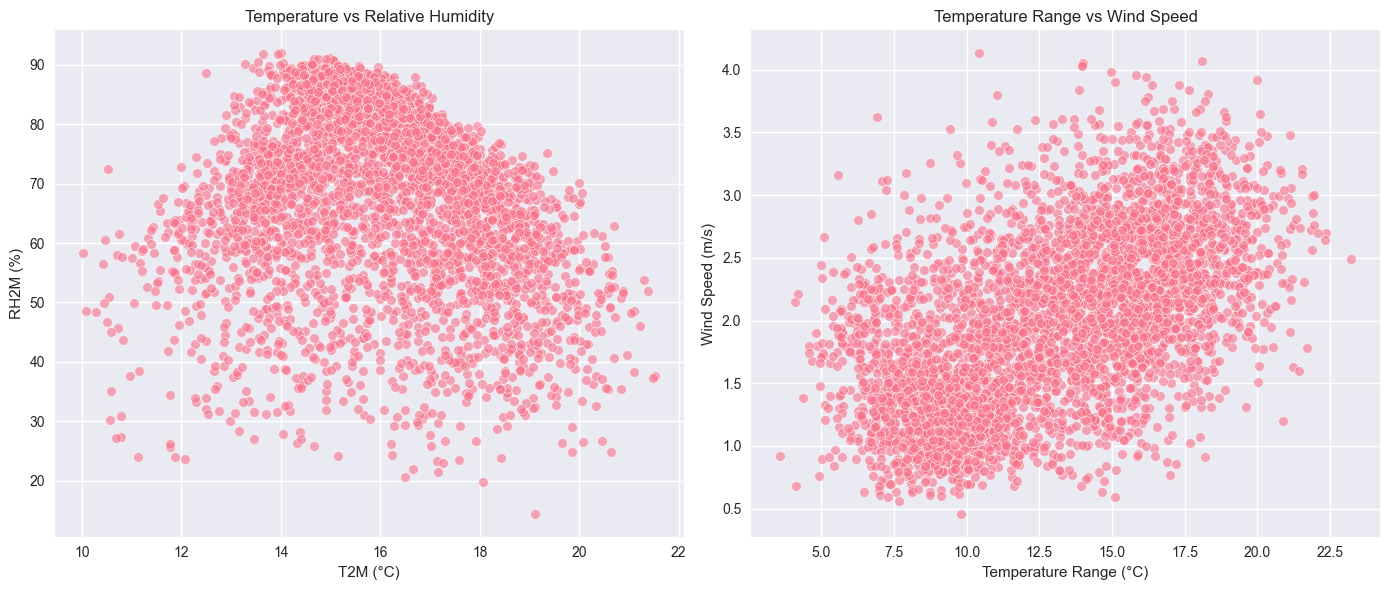

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# T2M vs RH2M
sns.scatterplot(data=df_clean, x='T2M', y='RH2M', alpha=0.6, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('T2M (°C)')
axes[0].set_ylabel('RH2M (%)')

# T2M_RANGE vs WS2M
sns.scatterplot(data=df_clean, x='T2M_RANGE', y='WS2M', alpha=0.6, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

C:\Users\elsam\climate-challenge-week0\venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


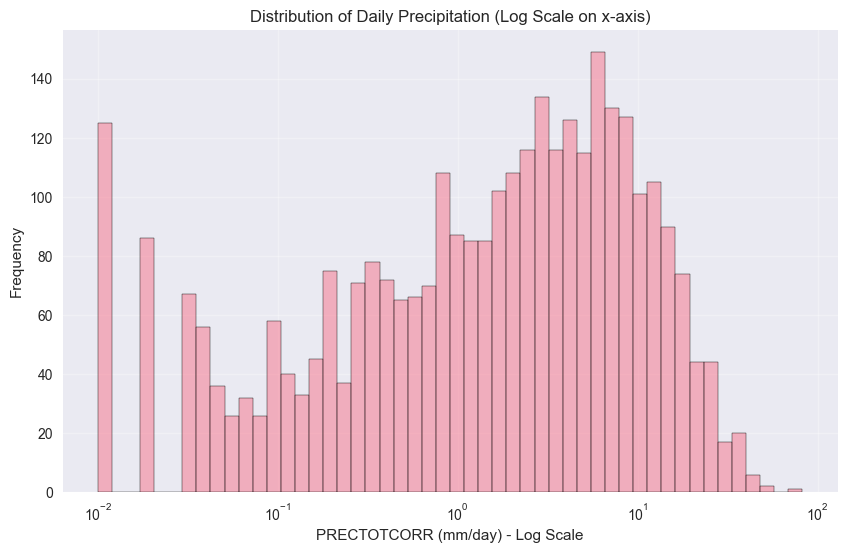

Skewness of PRECTOTCORR: 3.174521393838088


In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['PRECTOTCORR'], bins=50, kde=True, log_scale=(True, False))
plt.title('Distribution of Daily Precipitation (Log Scale on x-axis)')
plt.xlabel('PRECTOTCORR (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print("Skewness of PRECTOTCORR:", df_clean['PRECTOTCORR'].skew())

C:\Users\elsam\AppData\Local\Temp\ipykernel_18008\2927180610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='PRECTOTCORR', data=avg_monthly_precip, palette='Blues_d')


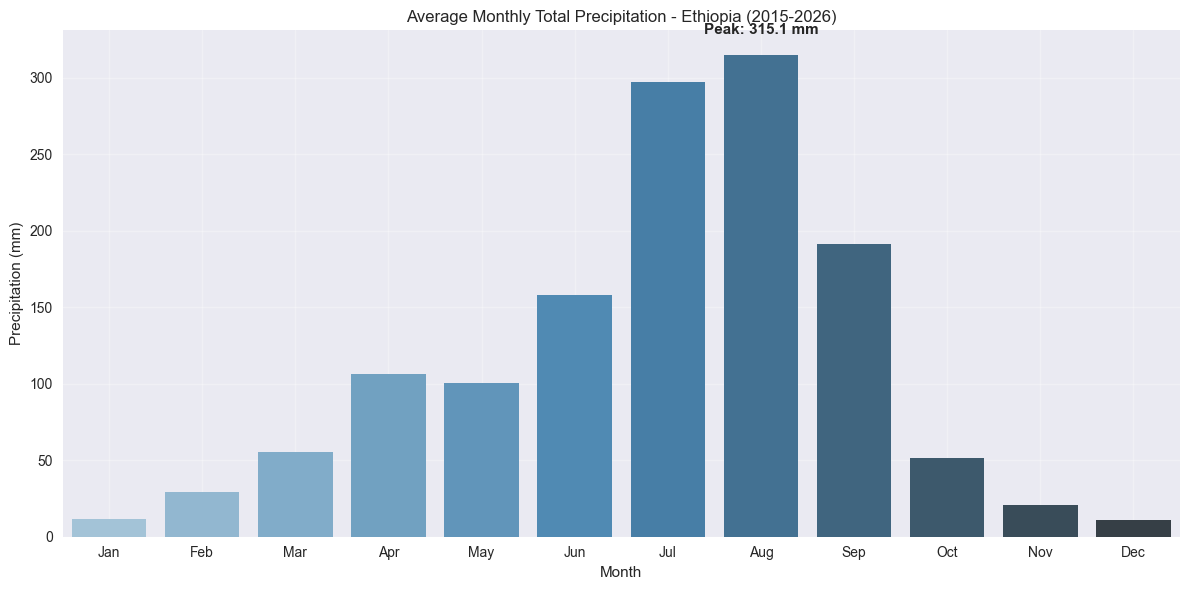

In [16]:
# === Monthly Total Precipitation Bar Chart ===
monthly_precip = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
avg_monthly_precip = monthly_precip.groupby('Month')['PRECTOTCORR'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='PRECTOTCORR', data=avg_monthly_precip, palette='Blues_d')
plt.title('Average Monthly Total Precipitation - Ethiopia (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)

# Annotate peak rainy season
peak = avg_monthly_precip.loc[avg_monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f'Peak: {peak["PRECTOTCORR"]:.1f} mm', 
             xy=(peak['Month']-1, peak['PRECTOTCORR']), 
             xytext=(0, 15), textcoords='offset points', 
             ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

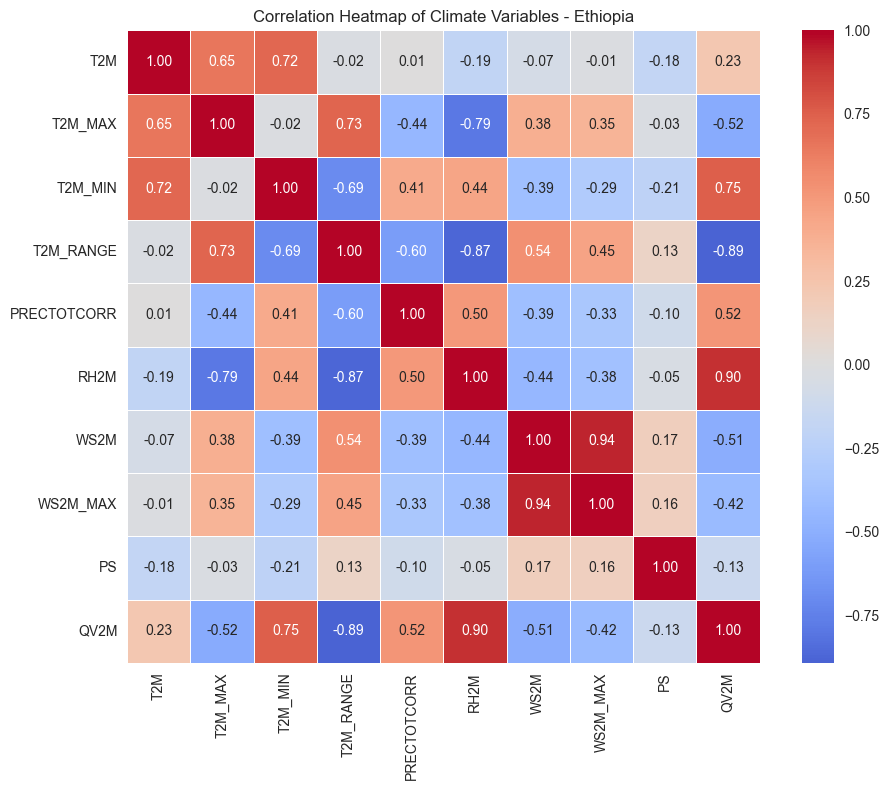

In [17]:
# === Correlation Heatmap ===
plt.figure(figsize=(10, 8))
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
             'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables - Ethiopia')
plt.tight_layout()
plt.show()

In [18]:
### Key Observations from Ethiopia EDA

**Data Quality:**
- Dataset has 4108 daily records from 2015-01-01 to 2026-03-31.
- No missing values after replacing -999 with NaN and forward filling.
- Very few outliers detected (e.g., 95 in PRECTOTCORR, ~2.3%).

**Temperature Trends:**
- Average T2M is around 16.07°C. 
- There is a visible slight warming trend over the years.

**Precipitation Patterns:**
- Precipitation is highly right-skewed (many dry days, few heavy rain days).
- Peak rainy season appears in **July–August** (typical for Ethiopia highlands).

**Strongest Correlations:**
- T2M and QV2M (specific humidity) — strong positive.
- T2M and RH2M — moderate negative (warmer air can hold more moisture).
- T2M_RANGE and WS2M — weak negative.

**Implications for COP32:**
- Increasing temperature combined with highly variable rainfall increases vulnerability to drought and floods in Ethiopia.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (4287358667.py, line 4)

In [29]:
### Key Observations from Ethiopia EDA

Data Quality:
- Dataset has 4108 daily records from 2015-1-1 to 2026-3-31.
- No missing values after replacing -999 with NaN and forward filling.
- Very few outliers detected (e.g., 95 in PRECTOTCORR, ~2.3%).

Temperature Trends:
- Average T2M is around 16.07 degree Celcius. 
- There is a visible slight warming trend over the years.

Precipitation Patterns:
- Precipitation is highly right-skewed (many dry days, few heavy rain days).
- Peak rainy season appears in **July to August** (typical for Ethiopia highlands).

Strongest Correlations:
- T2M and QV2M (specific humidity)  strong positive.
- T2M and RH2M  moderate negative (warmer air can hold more moisture).
- T2M_RANGE and WS2M  weak negative.

Implications for COP32:
- Increasing temperature combined with highly variable rainfall increases vulnerability to drought and floods in Ethiopia.

SyntaxError: invalid syntax (1487740401.py, line 3)